<h1><strong>Outliers</strong></h1>

An outlier is data points that differs significantly from other observations. 

In classroom where height of students is between 5 to 6 tall, but one student is 7.5 That student is an outlier.

In [1]:
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns


data = np.concatenate([np.random.normal(50,5,100),np.array([10,12,90,95,100])])

In [2]:
data

array([ 46.86637283,  40.47351262,  42.59546288,  54.02498016,
        49.67601909,  45.43385934,  47.55262008,  57.97966063,
        59.57593739,  44.11141417,  54.56591881,  56.88946233,
        52.24196388,  53.68214875,  49.93357992,  49.18893172,
        56.02015925,  51.25286623,  49.58677763,  52.6662618 ,
        48.35416052,  53.60060312,  45.08131547,  47.37857025,
        51.71403991,  50.84760119,  45.14585738,  42.19185228,
        45.17469001,  43.77038824,  58.40247286,  51.08753521,
        49.80338596,  53.81022834,  57.12351674,  46.99919403,
        41.97033442,  54.99193704,  50.42730003,  58.2787801 ,
        52.52184529,  54.5249137 ,  47.5889524 ,  51.59058713,
        42.67227452,  47.25094063,  47.91478619,  48.9804638 ,
        50.21862445,  49.57239508,  48.12332832,  46.28314329,
        41.12471198,  52.55856346,  38.04166755,  58.43733189,
        50.10843791,  43.80049026,  52.62744791,  59.12586147,
        55.94744819,  46.44180955,  47.75999255,  54.22

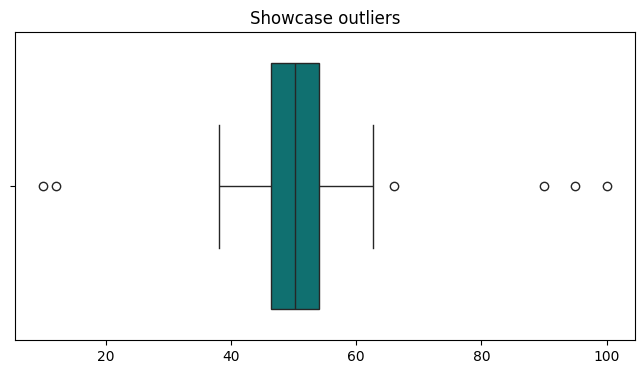

In [3]:
plt.figure(figsize=(8,4))
sns.boxplot(x=data,color='teal')
plt.title("Showcase outliers")
plt.show()

Scatter plots help to see outliers in relation to another variable.

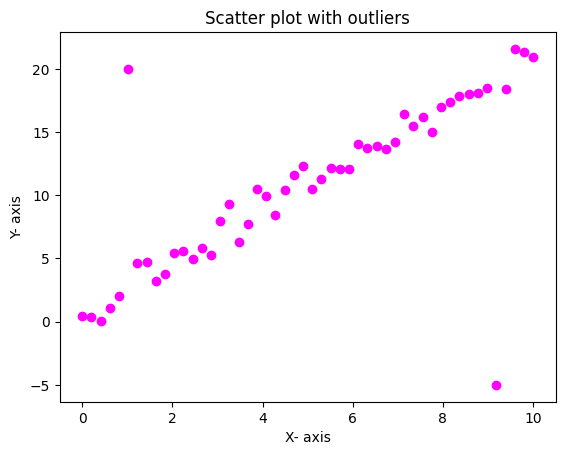

In [5]:
x= np.linspace(0,10,50)
y = 2 * x + 1 +np.random.normal(0,1,50)

y[5],y[45] = 20,-5

plt.scatter(x,y,color='magenta')
plt.title("Scatter plot with outliers")
plt.xlabel("X- axis")
plt.ylabel("Y- axis")
plt.show()

<h3><strong>Handling Outliers</strong></h3>

<strong>The IQR(Interquartile Range) Method</strong>

The IQR is the distance between the 25th percentile(Q1) and 75 percentile(Q3).

- Lower bound: Q1 - 1.5 x IQR
- Upper bound: Q3 + 1.5 x IQR

In [6]:
data

array([ 46.86637283,  40.47351262,  42.59546288,  54.02498016,
        49.67601909,  45.43385934,  47.55262008,  57.97966063,
        59.57593739,  44.11141417,  54.56591881,  56.88946233,
        52.24196388,  53.68214875,  49.93357992,  49.18893172,
        56.02015925,  51.25286623,  49.58677763,  52.6662618 ,
        48.35416052,  53.60060312,  45.08131547,  47.37857025,
        51.71403991,  50.84760119,  45.14585738,  42.19185228,
        45.17469001,  43.77038824,  58.40247286,  51.08753521,
        49.80338596,  53.81022834,  57.12351674,  46.99919403,
        41.97033442,  54.99193704,  50.42730003,  58.2787801 ,
        52.52184529,  54.5249137 ,  47.5889524 ,  51.59058713,
        42.67227452,  47.25094063,  47.91478619,  48.9804638 ,
        50.21862445,  49.57239508,  48.12332832,  46.28314329,
        41.12471198,  52.55856346,  38.04166755,  58.43733189,
        50.10843791,  43.80049026,  52.62744791,  59.12586147,
        55.94744819,  46.44180955,  47.75999255,  54.22

In [7]:
Q1 = np.percentile(data,25)
Q3 = np.percentile(data,75)

IQR = Q3 - Q1

In [10]:
IQR

np.float64(7.5831706077437815)

In [15]:
Q1 - 1.5 * IQR

np.float64(35.06705363924661)

In [16]:
Q3 + 1.5 * IQR

np.float64(65.39973607022173)

In [11]:
filtered_data = data[(data>=Q1 - 1.5 * IQR)&(data<=Q3 + 1.5 * IQR)]

99

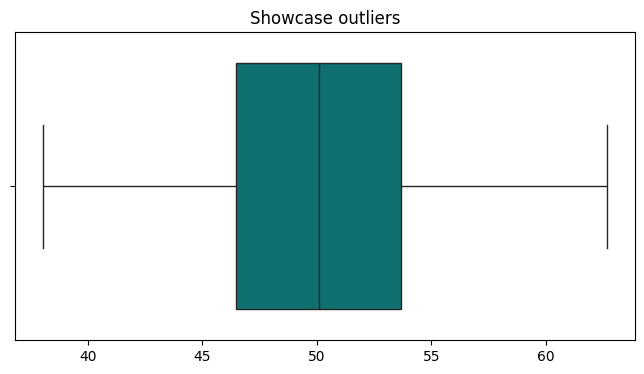

In [13]:
plt.figure(figsize=(8,4))
sns.boxplot(x=filtered_data,color='teal')
plt.title("Showcase outliers")
plt.show()

<h3><strong>Z-Score Method</strong></h3>

The Z-score tells you how many standard deviations a point is from the mean. Typically, any point with a z-score > 3 or < -3 is an outlier.

Z = x - u / std

In [17]:
from scipy import stats

z_scores = np.abs(stats.zscore(data))

In [19]:
data

array([ 46.86637283,  40.47351262,  42.59546288,  54.02498016,
        49.67601909,  45.43385934,  47.55262008,  57.97966063,
        59.57593739,  44.11141417,  54.56591881,  56.88946233,
        52.24196388,  53.68214875,  49.93357992,  49.18893172,
        56.02015925,  51.25286623,  49.58677763,  52.6662618 ,
        48.35416052,  53.60060312,  45.08131547,  47.37857025,
        51.71403991,  50.84760119,  45.14585738,  42.19185228,
        45.17469001,  43.77038824,  58.40247286,  51.08753521,
        49.80338596,  53.81022834,  57.12351674,  46.99919403,
        41.97033442,  54.99193704,  50.42730003,  58.2787801 ,
        52.52184529,  54.5249137 ,  47.5889524 ,  51.59058713,
        42.67227452,  47.25094063,  47.91478619,  48.9804638 ,
        50.21862445,  49.57239508,  48.12332832,  46.28314329,
        41.12471198,  52.55856346,  38.04166755,  58.43733189,
        50.10843791,  43.80049026,  52.62744791,  59.12586147,
        55.94744819,  46.44180955,  47.75999255,  54.22

In [28]:
filtered_data_z = data[z_scores<3]

In [33]:
z_scores

array([3.49113173e-01, 9.45731256e-01, 7.47698786e-01, 3.18968788e-01,
       8.69009997e-02, 4.82803482e-01, 2.85068676e-01, 6.88042067e-01,
       8.37015697e-01, 6.06221588e-01, 3.69452261e-01, 5.86298560e-01,
       1.52567565e-01, 2.86973810e-01, 6.28639576e-02, 1.32358764e-01,
       5.05170252e-01, 6.02593461e-02, 9.52295202e-02, 1.92165462e-01,
       2.10264362e-01, 2.79363508e-01, 5.15704881e-01, 3.01311996e-01,
       1.03298698e-01, 2.24377070e-02, 5.09681462e-01, 7.85366024e-01,
       5.06990637e-01, 6.38048068e-01, 7.27501310e-01, 4.48297141e-02,
       7.50143989e-02, 2.98926927e-01, 6.08141850e-01, 3.36717543e-01,
       8.06039330e-01, 4.09210705e-01, 1.67871885e-02, 7.15957598e-01,
       1.78687690e-01, 3.65625430e-01, 2.81677937e-01, 9.17773820e-02,
       7.40530287e-01, 3.13223118e-01, 2.51269273e-01, 1.51814177e-01,
       3.62619809e-02, 9.65717818e-02, 2.31806936e-01, 4.03543472e-01,
       8.84957628e-01, 1.82114440e-01, 1.17268487e+00, 7.30754553e-01,
      

In [32]:
z_scores<3

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False, False, False, False, False])

In [30]:
filtered_data_z

array([46.86637283, 40.47351262, 42.59546288, 54.02498016, 49.67601909,
       45.43385934, 47.55262008, 57.97966063, 59.57593739, 44.11141417,
       54.56591881, 56.88946233, 52.24196388, 53.68214875, 49.93357992,
       49.18893172, 56.02015925, 51.25286623, 49.58677763, 52.6662618 ,
       48.35416052, 53.60060312, 45.08131547, 47.37857025, 51.71403991,
       50.84760119, 45.14585738, 42.19185228, 45.17469001, 43.77038824,
       58.40247286, 51.08753521, 49.80338596, 53.81022834, 57.12351674,
       46.99919403, 41.97033442, 54.99193704, 50.42730003, 58.2787801 ,
       52.52184529, 54.5249137 , 47.5889524 , 51.59058713, 42.67227452,
       47.25094063, 47.91478619, 48.9804638 , 50.21862445, 49.57239508,
       48.12332832, 46.28314329, 41.12471198, 52.55856346, 38.04166755,
       58.43733189, 50.10843791, 43.80049026, 52.62744791, 59.12586147,
       55.94744819, 46.44180955, 47.75999255, 54.22977771, 52.91742822,
       41.54817913, 55.02434539, 50.58766891, 50.98728455, 47.06

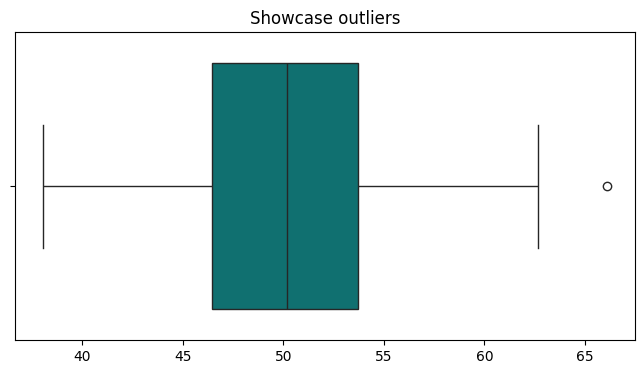

In [29]:
plt.figure(figsize=(8,4))
sns.boxplot(x=filtered_data_z,color='teal')
plt.title("Showcase outliers")
plt.show()